# Austin 911 Baker Sector Pipeline

## 1. Imports & Logging

In [ ]:
import os
import subprocess
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import logging

from dotenv import load_dotenv, find_dotenv
import pymongo
from pymongo import MongoClient
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor

In [47]:
LOGS_DIR = Path("logs")
LOGS_DIR.mkdir(exist_ok=True)

log = logging.getLogger("model_pipeline")
log.setLevel(logging.INFO)
log.propagate = False  # prevent duplicate lines from the root logger

_fmt = logging.Formatter("%(asctime)s  %(levelname)-8s  %(message)s", datefmt="%H:%M:%S")

_ch = logging.StreamHandler()
_ch.setFormatter(_fmt)

_fh = logging.FileHandler(LOGS_DIR / "model.log", mode="w")  # persists after run
_fh.setFormatter(_fmt)

if not log.handlers:
    log.addHandler(_ch)
    log.addHandler(_fh)

log.info("Logging initialized — file: %s", LOGS_DIR / "model.log")

23:41:48  INFO      Logging initialized — file: logs/model.log


## 2. Config

Load environment variables (MongoDB URI) and set up the output directory for saved plots.

In [48]:
PROCESSED = Path("data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

load_dotenv(find_dotenv(), override=True)
MONGO_URI       = os.getenv("MONGO_URI")
DB_NAME         = "austin_911"
COLLECTION_NAME = "calls"

log.info("MongoDB target: %s > %s", DB_NAME, COLLECTION_NAME)

23:41:48  INFO      MongoDB target: austin_911 > calls


## 3. MongoDB Query


In [49]:
# Connect to MongoDB Atlas
client = MongoClient(MONGO_URI, connect=False)
db = client[DB_NAME]
collection = db[COLLECTION_NAME]

db         = client[DB_NAME]
collection = db[COLLECTION_NAME]

In [37]:
# Pull all documents from the calls collection into a DataFrame
try:
    df_from_mongo = pd.DataFrame(list(collection.find({})))
    log.info("Query shape   : %s", df_from_mongo.shape)
    log.info("Columns       : %s", list(df_from_mongo.columns))
except pymongo.errors.PyMongoError as e:
    log.error("MongoDB query failed: %s", e)
    raise
finally:
    client.close()
    log.info("MongoDB connection closed")

23:41:47  INFO      Query shape   : (17399, 34)
23:41:47  INFO      Columns       : ['_id', 'incident_type', 'mental_health_flag', 'priority_level', 'response_datetime', 'response_hour', 'initial_problem_category', 'final_problem_category', 'number_of_units_arrived', 'unit_time_on_scene', 'response_time', 'officer_injured_killed_count', 'subject_injured_killed_count', 'geo_id', 'census_block_group', 'date', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'windspeed_10m_max', 'weathercode', 'day_of_week', 'month', 'day_of_year', 'is_weekend', 'season', 'is_holiday', 'is_ut_game', 'is_sxsw', 'is_acl', 'is_ut_movein', 'is_spring_break', 'is_graduation', 'split']
23:41:47  INFO      MongoDB connection closed


## 4. Train/Test Split & Daily Aggregation

Split the call-level records by the `split` label inserted during ingestion (2025 = train, 2024 = test), then aggregate to one row per day. Operational columns (response time, units, scene time, mental health rate, Priority 0 rate) are averaged; date/event/weather columns are carried forward using the first value of each day since they are constant within a day.

In [38]:
# Separate call-level records into train (2025) and test (2024) using the pre-labeled split column
df_train = df_from_mongo[df_from_mongo["split"] == "train"].copy()
df_test  = df_from_mongo[df_from_mongo["split"] == "test"].copy()

log.info("Call-level — train (2025): %d rows, test (2024): %d rows",
         len(df_train), len(df_test))


def aggregate_daily(df: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse call-level records to one row per calendar day.
    Computes operational metrics via aggregation and carries forward
    constant date/event/weather columns using the first row of each day.
    """
    daily = df.groupby("date").agg(
        call_count        = ("_id",                    "count"),
        avg_response_time = ("response_time",           "mean"),
        avg_units_arrived = ("number_of_units_arrived", "mean"),
        avg_time_on_scene = ("unit_time_on_scene",      "mean"),
        # fraction of calls flagged as mental health incidents on that day
        pct_mental_health = ("mental_health_flag",
                             lambda x: (x == "Mental Health Incident").mean()),
        # fraction of calls that were the most urgent level (Priority 0)
        pct_priority_0    = ("priority_level",
                             lambda x: (x == "Priority 0").mean()),
        # date / event / weather features are constant within a day — take first value
        **{col: (col, "first") for col in [
            "is_holiday", "is_ut_game", "is_sxsw", "is_acl",
            "is_ut_movein", "is_spring_break", "is_graduation",
            "day_of_week", "month", "day_of_year",
            "temperature_2m_max", "temperature_2m_min",
            "precipitation_sum", "windspeed_10m_max",
        ]},
    ).reset_index()
    daily["date"] = pd.to_datetime(daily["date"])
    return daily


daily_train = aggregate_daily(df_train)
daily_test  = aggregate_daily(df_test)

log.info("Daily train : %s (%d days)", daily_train.shape, len(daily_train))
log.info("Daily test  : %s (%d days)", daily_test.shape,  len(daily_test))

23:41:47  INFO      Call-level — train (2025): 8453 rows, test (2024): 8946 rows
23:41:47  INFO      Daily train : (365, 21) (365 days)
23:41:47  INFO      Daily test  : (366, 21) (366 days)


## 5. Feature Engineering, Modeling & Evaluation

The feature matrix was constructed from three categories of predictors: temporal features derived from the date, weather features from the Open-Meteo API, and binary event flags engineered from publicly available event schedules. Three features: is_weekend, total_officer_injured, and total_subject_injured, were dropped after an initial model run revealed zero importance scores for all three. is_weekend had collinearity with day_of_week, which already encodes which specific day each observation falls on, and the injury count fields were near zero across the entire dataset.

Linear regression was selected as the baseline model because it is fully interpretable and provides a meaningful lower bound on model complexity. XGBoost was selected as the primary model because it is a strong general purpose algorithm for tabular data, handles mixed feature types natively, and can capture non-linear interactions between features. For example, the combined effect of a UT game day occurring during an extremely hot day. The XGBoost had a marginally better performance, suggesting the feature relationships in this dataset are largely linear at the daily aggregation level.

In [39]:
feature_cols = [
    "day_of_week", "month", "day_of_year",
    "is_holiday", "is_ut_game", "is_sxsw", "is_acl",
    "is_ut_movein", "is_spring_break", "is_graduation",
    "temperature_2m_max", "temperature_2m_min",
    "precipitation_sum", "windspeed_10m_max",
    "avg_response_time", "avg_units_arrived", "avg_time_on_scene",
    "pct_mental_health", "pct_priority_0"
]


In [40]:
X_train = daily_train[feature_cols]
y_train = daily_train["call_count"]
X_test  = daily_test[feature_cols]
y_test  = daily_test["call_count"]

log.info("X_train: %s  |  X_test: %s", X_train.shape, X_test.shape)
log.info("y_train mean: %.1f calls/day  |  y_test mean: %.1f calls/day",
         y_train.mean(), y_test.mean())

23:41:47  INFO      X_train: (365, 19)  |  X_test: (366, 19)
23:41:47  INFO      y_train mean: 23.2 calls/day  |  y_test mean: 24.4 calls/day


In [41]:
# Lin regression model to compare to xgboost
try:
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_preds = lr.predict(X_test)
except Exception as e:
    log.error("Linear regression failed: %s", e)
    raise

lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_rmse = root_mean_squared_error(y_test, lr_preds)

log.info("Linear Regression (baseline) -----------")
log.info("  MAE  : %.2f calls/day", lr_mae)
log.info("  RMSE : %.2f calls/day", lr_rmse)

23:41:47  INFO      Linear Regression (baseline) -----------
23:41:47  INFO        MAE  : 4.51 calls/day
23:41:47  INFO        RMSE : 5.61 calls/day


In [42]:
# xgboost regression with early stopping and regularization
try:
    xgb = XGBRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbosity=0,
        )
    xgb.fit(X_train, y_train)
    xgb_preds = xgb.predict(X_test)
except Exception as e:
    log.error("XGBoost training failed: %s", e)
    raise

xgb_mae  = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = root_mean_squared_error(y_test, xgb_preds)

log.info("XGBoost -----------------------")
log.info("  MAE  : %.2f calls/day", xgb_mae)
log.info("  RMSE : %.2f calls/day", xgb_rmse)

23:41:47  INFO      XGBoost -----------------------
23:41:47  INFO        MAE  : 4.42 calls/day
23:41:47  INFO        RMSE : 5.49 calls/day


In [43]:
# Summary
metrics_df = pd.DataFrame({
    "Model": ["Linear Regression (baseline)", "XGBoost"],
    "MAE (calls/day)":  [round(lr_mae,  2), round(xgb_mae,  2)],
    "RMSE (calls/day)": [round(lr_rmse, 2), round(xgb_rmse, 2)],
}).set_index("Model")

print(metrics_df.to_string())
log.info("Evaluation summary:\n%s", metrics_df.to_string())

23:41:47  INFO      Evaluation summary:
                              MAE (calls/day)  RMSE (calls/day)
Model                                                          
Linear Regression (baseline)             4.51              5.61
XGBoost                                  4.42              5.49


                              MAE (calls/day)  RMSE (calls/day)
Model                                                          
Linear Regression (baseline)             4.51              5.61
XGBoost                                  4.42              5.49


## 6. Visualization

Two plots saved to `data/processed/`:
- **`feature_importance.png`** — XGBoost gain-based feature importance (horizontal bar)
- **`actual_vs_predicted.png`** — time-series of actual vs. XGBoost predicted daily call counts 

Two visualizations were produced to communicate the modeling results. The first is an actual vs. predicted time series plot showing daily Priority 0/1 call volume across all of 2024, with XGBoost predictions overlaid as a dashed line and a shaded +-MAE band indicating the model's typical error range. Key events,  SXSW and UT home football game days, are annotated directly on the plot so the reader can visually assess whether the model responds appropriately to those features. This plot was chosen because time series data is most naturally communicated as a line chart, and the event annotations tie the visualization directly back to the core research question of whether public events drive call volume. 

The second visualization is a horizontal bar chart of XGBoost feature importance scores, with event features colored separately from operational and weather features. This was chosen to make the relative contribution of each predictor readable, and the color distinction highlights the specific contribution of the engineered event features (the primary contribution of this dataset) relative to more standard predictors like temperature and day of week.

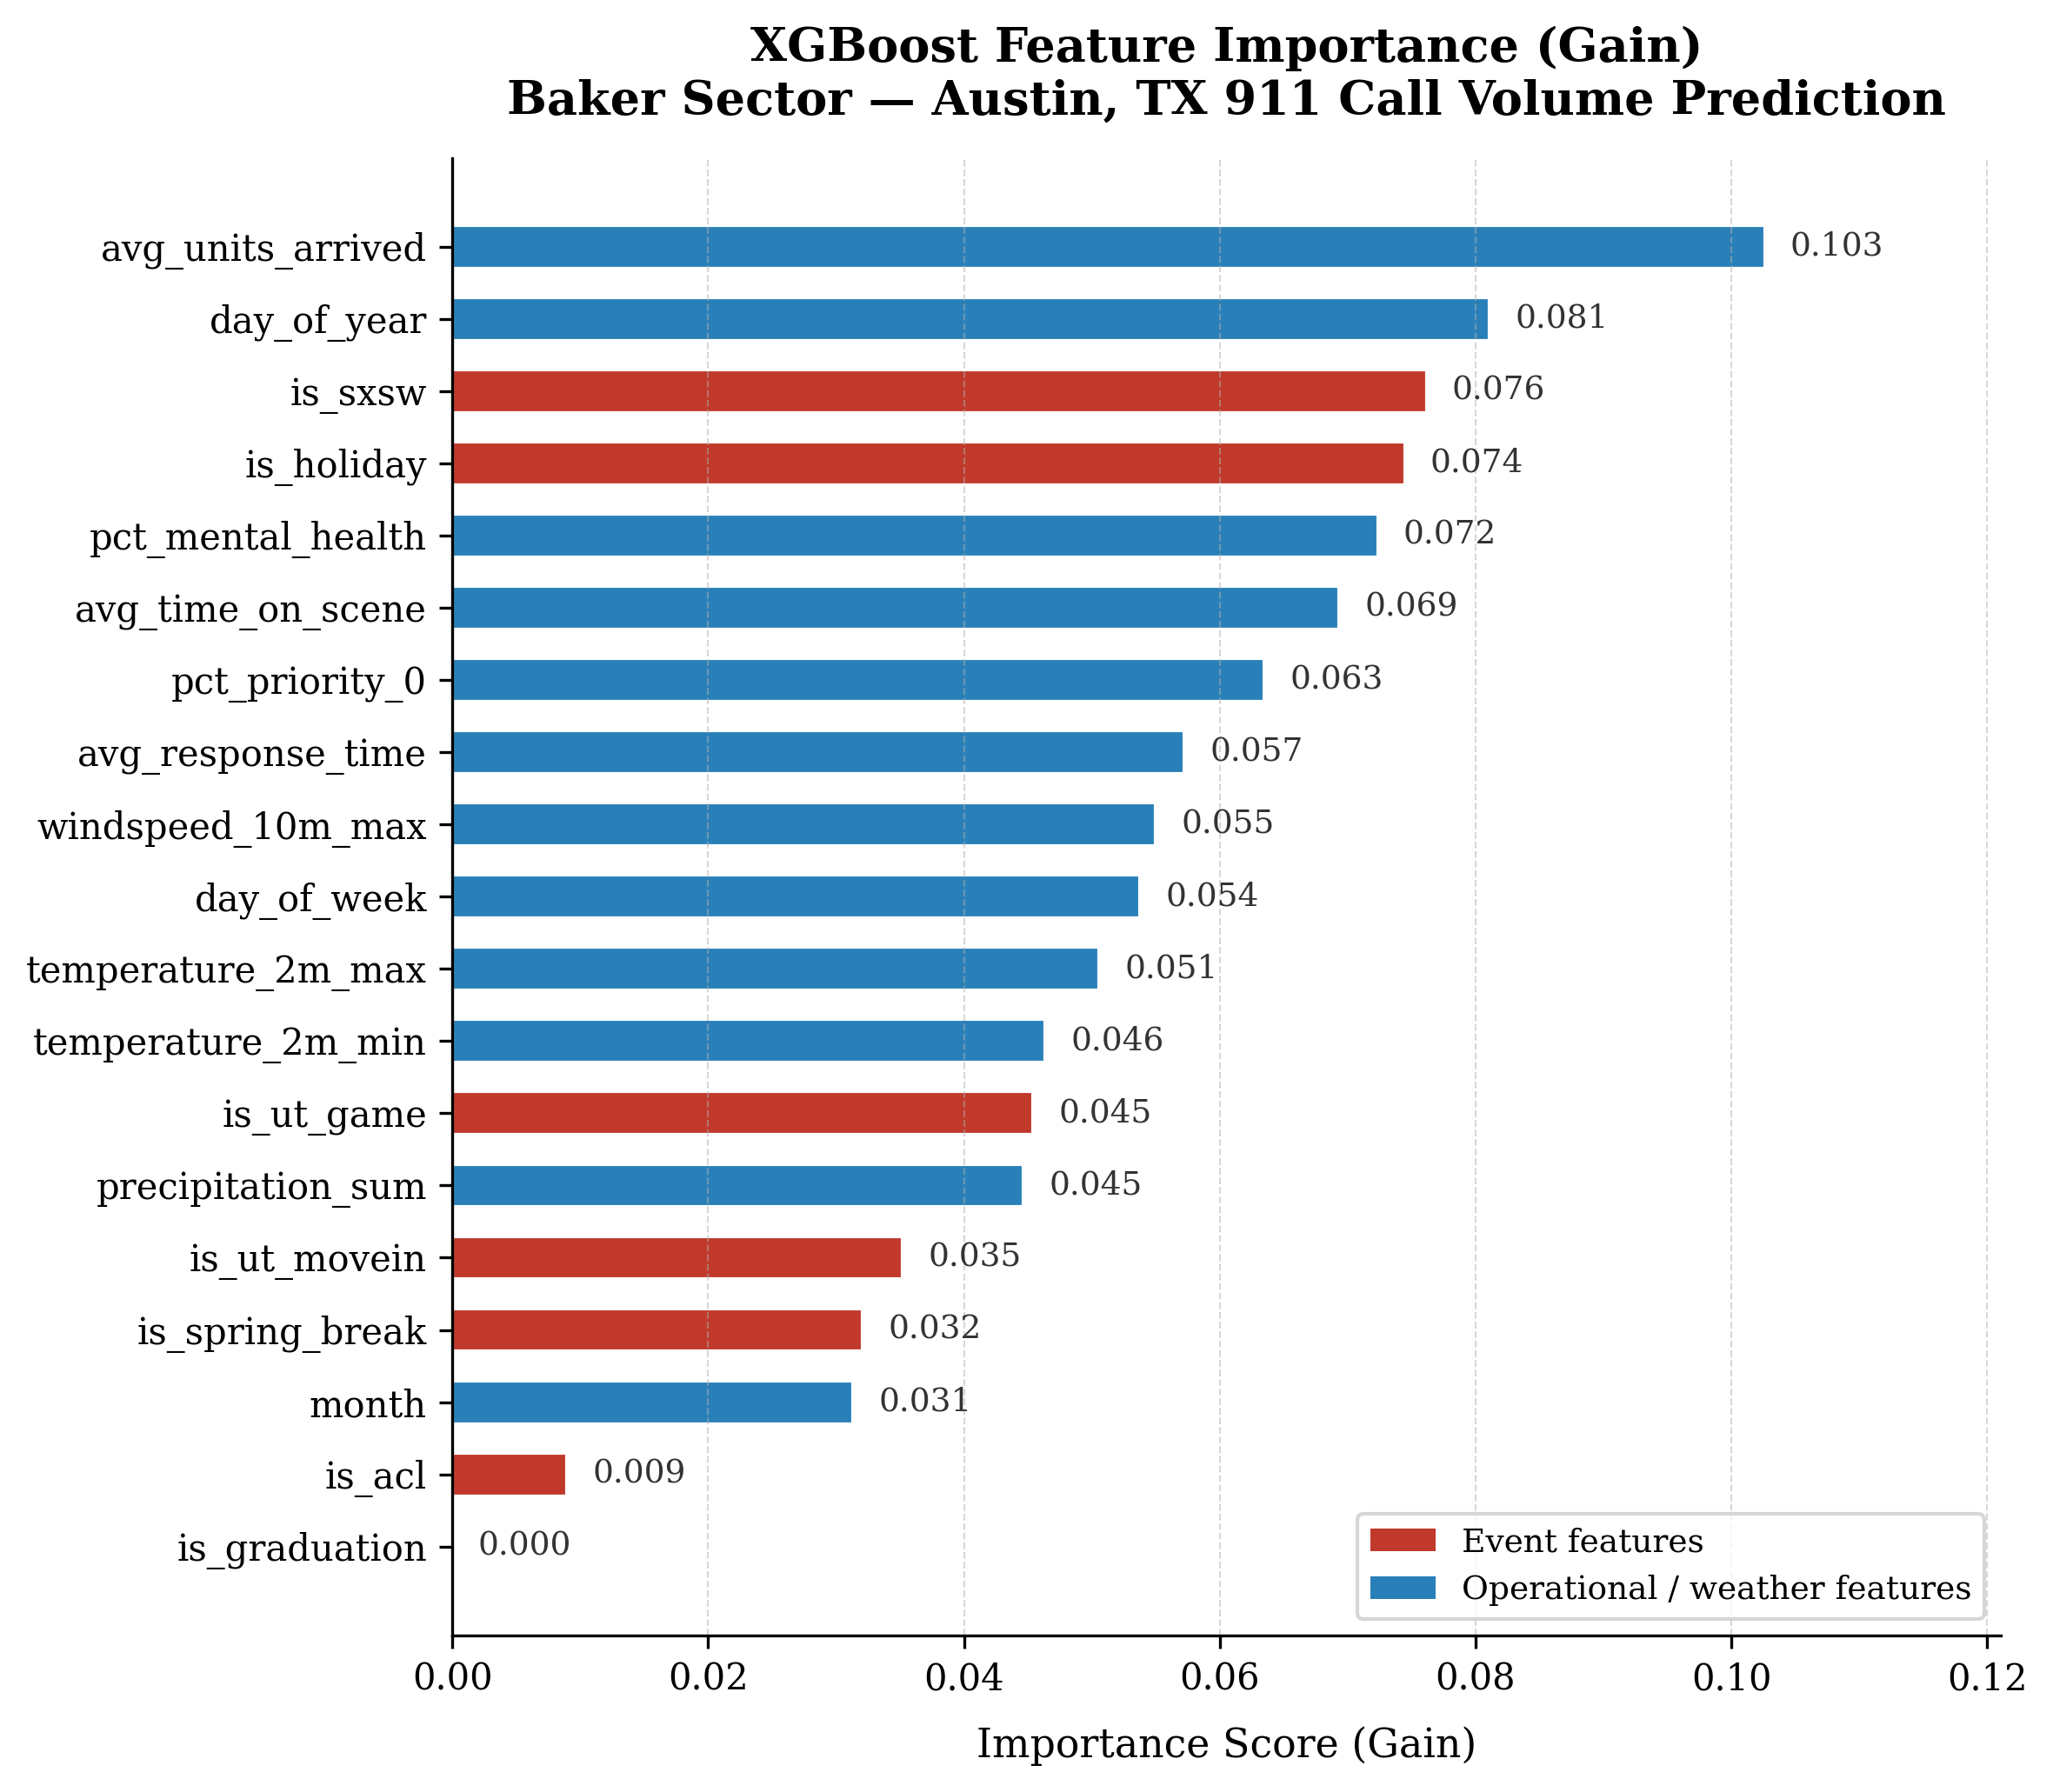

00:06:29  INFO      Feature importance (descending):
avg_units_arrived     0.102608
day_of_year           0.081106
is_sxsw               0.076165
is_holiday            0.074462
pct_mental_health     0.072355
avg_time_on_scene     0.069340
pct_priority_0        0.063472
avg_response_time     0.057224
windspeed_10m_max     0.054984
day_of_week           0.053741
temperature_2m_max    0.050598
temperature_2m_min    0.046382
is_ut_game            0.045384
precipitation_sum     0.044638
is_ut_movein          0.035206
is_spring_break       0.032071
month                 0.031311
is_acl                0.008953
is_graduation         0.000000


In [56]:
# settings
mpl.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "figure.dpi":       300,
})

# feature importance 
importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)

# Color event features differently from operational/weather features
colors = ["#c0392b" if "is_" in i else "#2980b9" for i in importance.index]

fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.barh(importance.index, importance.values, color=colors, edgecolor="white", height=0.6)

# Add value labels on bars
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left", fontsize=9, color="#333333")

ax.set_title("XGBoost Feature Importance (Gain)\nBaker Sector — Austin, TX 911 Call Volume Prediction",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Importance Score (Gain)", labelpad=8)
ax.set_xlim(0, importance.max() * 1.18)

# Legend
legend_elements = [
    Patch(facecolor="#c0392b", label="Event features"),
    Patch(facecolor="#2980b9", label="Operational / weather features")
]
ax.legend(handles=legend_elements, loc="lower right", frameon=True, fontsize=9)

ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(PROCESSED / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

log.info("Feature importance (descending):\n%s",
         importance.sort_values(ascending=False).to_string())

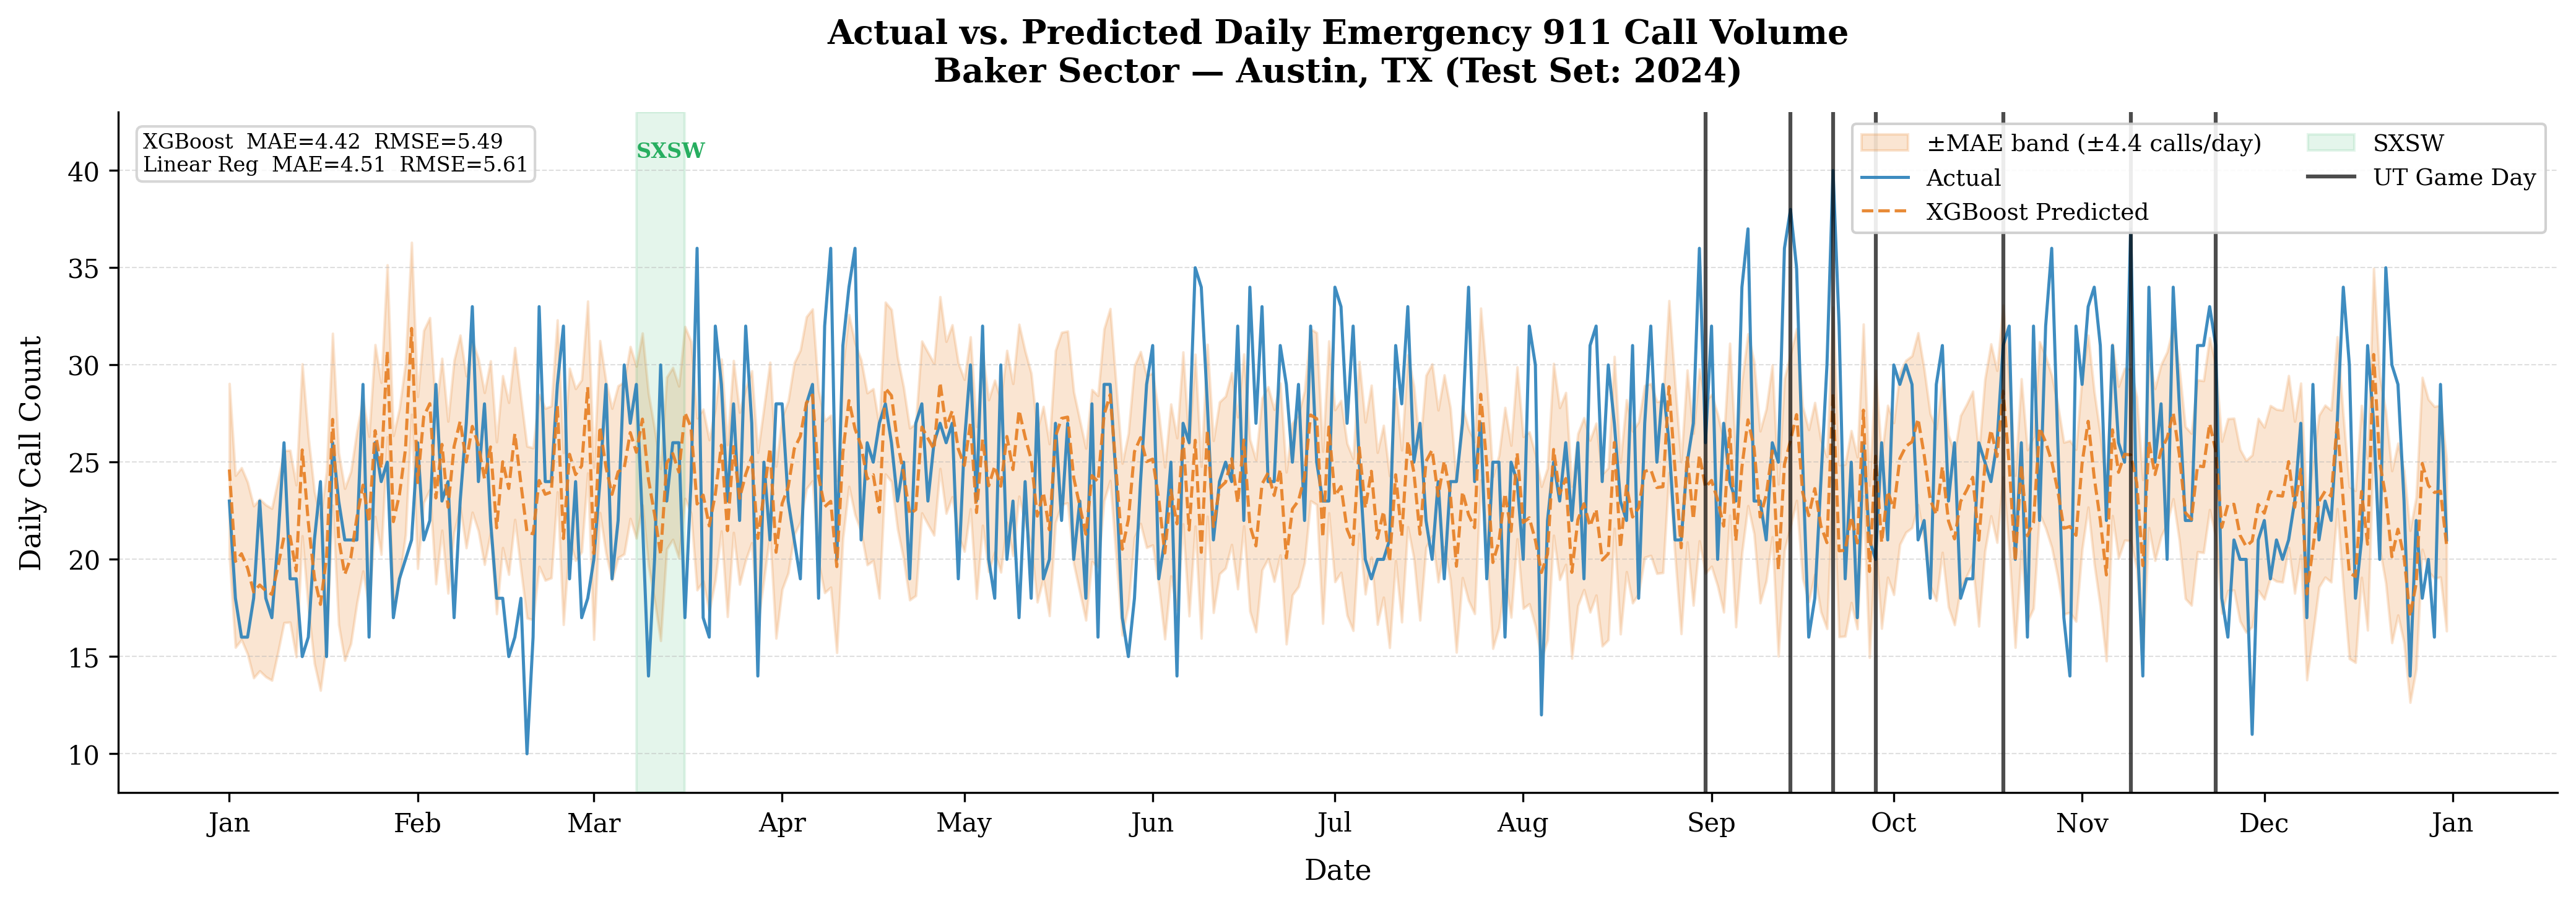

In [57]:
plot_df = daily_test.copy()
plot_df["xgb_pred"] = xgb_preds
plot_df = plot_df.sort_values("date").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

# +- MAE shaded band around XGBoost predictions
ax.fill_between(
    plot_df["date"],
    plot_df["xgb_pred"] - xgb_mae,
    plot_df["xgb_pred"] + xgb_mae,
    alpha=0.20, color="#e67e22",
    label=f"±MAE band (±{xgb_mae:.1f} calls/day)"
)

# plot results
ax.plot(plot_df["date"], plot_df["call_count"],
        color="#2980b9", linewidth=1.2, alpha=0.9, label="Actual")
ax.plot(plot_df["date"], plot_df["xgb_pred"],
        color="#e67e22", linewidth=1.2, linestyle="--", alpha=0.9, label="XGBoost Predicted")

# Shade SXSW days
sxsw_days = plot_df.loc[plot_df["is_sxsw"] == 1, "date"]
if len(sxsw_days):
    ax.axvspan(sxsw_days.min(), sxsw_days.max(),
               alpha=0.12, color="#27ae60", label="SXSW")
    ax.text(sxsw_days.min(), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 40,
            "SXSW", fontsize=8, color="#27ae60", va="top", ha="left", fontweight="bold")

# Game day lines
game_dates = plot_df.loc[plot_df["is_ut_game"] == 1, "date"].tolist()
for i, d in enumerate(game_dates):
    ax.axvline(d, color="black", linewidth=1.5, alpha=0.7,
               label="UT Game Day" if i == 0 else None)

# Formatting
ax.set_title(
    "Actual vs. Predicted Daily Emergency 911 Call Volume\nBaker Sector — Austin, TX (Test Set: 2024)",
    fontsize=13, fontweight="bold", pad=12
)
ax.set_xlabel("Date", labelpad=8)
ax.set_ylabel("Daily Call Count", labelpad=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.4)
ax.set_ylim(bottom=0, top=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.9,
          edgecolor="#cccccc", ncol=2)

# metrics upper left
ax.text(0.01, 0.97,
        f"XGBoost  MAE={xgb_mae:.2f}  RMSE={xgb_rmse:.2f}\nLinear Reg  MAE={lr_mae:.2f}  RMSE={lr_rmse:.2f}",
        transform=ax.transAxes, fontsize=8, va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#cccccc", alpha=0.8))

ax.set_ylim(bottom=8, top=43)
plt.tight_layout()
plt.savefig(PROCESSED / "actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()